<a href="https://colab.research.google.com/github/ashycoding/Deep-Learning-Labs/blob/main/BrainTumor_Explained.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor Detection using CNN

This notebook trains a **Convolutional Neural Network (CNN)** to classify brain MRI images as either having a tumor or not.

---

### What does this notebook do?
1. Loads brain MRI images from Google Drive
2. Applies data augmentation to improve model generalization
3. Builds a CNN model from scratch
4. Trains the model with early stopping
5. Evaluates model accuracy
6. Plots training and validation curves

---

## Step 1 — Import Libraries

We import the tools we need:
- **TensorFlow / Keras** — for building and training the neural network
- **Matplotlib** — for plotting accuracy and loss graphs
- `ImageDataGenerator` — loads images and applies augmentation on-the-fly
- `EarlyStopping` — automatically stops training when the model stops improving


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

## Step 2 — Set Hyperparameters

Before training, we define a few key settings:

| Parameter | Value | Meaning |
|-----------|-------|----------|
| `img_size` | 224 | Resize all images to 224×224 pixels |
| `batch_size` | 32 | Process 32 images at a time during training |
| `epochs` | 15 | Maximum number of training rounds |

> **Note:** We use `EarlyStopping` (defined later), so the model may stop before reaching 15 epochs if it's no longer improving.


In [2]:
img_size = 224      # All images will be resized to 224x224 pixels
batch_size = 32     # Number of images processed per training step
epochs = 15         # Maximum training iterations

## Step 3 — Data Augmentation

Since we have a small dataset (only ~250 images), we use **data augmentation** to artificially increase variety.

This means the model sees slightly different versions of the same image every epoch — reducing overfitting.

We apply:
- **`rescale=1./255`** — Normalize pixel values from [0, 255] → [0, 1] for stable training
- **`rotation_range=20`** — Randomly rotate images up to 20 degrees
- **`zoom_range=0.2`** — Randomly zoom in/out by 20%
- **`horizontal_flip=True`** — Randomly mirror images left–right
- **`validation_split=0.2`** — Reserve 20% of the data for validation (not used for training)


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixel values to range [0, 1]
    rotation_range=20,       # Random rotation augmentation
    zoom_range=0.2,          # Random zoom augmentation
    horizontal_flip=True,    # Random left-right flip augmentation
    validation_split=0.2     # 20% of data reserved for validation
)

## Step 4 — Mount Google Drive

We mount Google Drive so we can access the brain MRI dataset stored there.

After running this cell, you may be prompted to authorize access.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 5 — Load Training and Validation Data

We use `flow_from_directory` to automatically:
- Read images from labeled subfolders (each subfolder = one class)
- Resize them to 224×224
- Apply the augmentation we defined above

**Training set** → 80% of the images (used to train the model)

**Validation set** → 20% of the images (used to measure performance on unseen data)

Both generators pull from the **same folder** but use different splits.


In [5]:
# Load 80% of images as training data
train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/brain_dataset/train",
    target_size=(img_size, img_size),  # Resize images to 224x224
    batch_size=batch_size,
    class_mode='categorical',          # Multi-class one-hot labels
    subset='training'                  # Use the training split
)

Found 203 images belonging to 2 classes.


In [6]:
# Load 20% of images as validation data (no augmentation applied at inference)
val_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/brain_dataset/train",
    target_size=(img_size, img_size),  # Resize images to 224x224
    batch_size=batch_size,
    class_mode='categorical',          # Multi-class one-hot labels
    subset='validation'                # Use the validation split
)

Found 50 images belonging to 2 classes.


## Step 6 — Build the CNN Model

We build a **Sequential CNN** — layers stacked one after another.

### Architecture Overview

```
Input (224×224×3)
   ↓
Conv2D(16) → MaxPool       ← Detects basic edges/patterns
   ↓
Conv2D(32) → MaxPool       ← Detects more complex features
   ↓
Conv2D(64) → MaxPool       ← Detects high-level features
   ↓
Flatten
   ↓
Dense(128, ReLU)
   ↓
Dropout(0.5)               ← Prevents overfitting
   ↓
Dense(2, Softmax)          ← Output: [P(no tumor), P(tumor)]
```

**Conv2D** — Learns spatial features from the image

**MaxPooling2D** — Reduces spatial size, keeping the most important features

**Dropout(0.5)** — Randomly turns off 50% of neurons during training to prevent overfitting

**Softmax** — Converts final scores into probabilities (they sum to 1)


In [7]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),      # Input: RGB image of size 224x224

    # Block 1 — Detect basic features (edges, textures)
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Block 2 — Detect intermediate features
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Block 3 — Detect complex/high-level features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),                        # Convert 3D feature maps to 1D vector

    layers.Dense(128, activation='relu'),    # Fully connected layer
    layers.Dropout(0.5),                     # Regularization: drop 50% neurons randomly

    layers.Dense(2, activation='softmax')    # Output: probability for each class (tumor / no tumor)
])

## Step 7 — Compile the Model

Before training, we configure how the model learns:

- **Optimizer: Adam** (lr=0.0001) — Adjusts model weights step by step; a small learning rate means slower but more stable updates
- **Loss: Categorical Crossentropy** — Standard loss function for multi-class classification
- **Metrics: Accuracy** — We track accuracy to monitor performance during training


In [8]:
# Adam optimizer with a small learning rate for stable convergence
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',   # Loss for multi-class classification
    metrics=['accuracy']               # Monitor accuracy during training
)

## Step 8 — Early Stopping

We use **Early Stopping** to prevent wasting time and avoid overfitting.

- **`monitor='val_loss'`** — Watch the validation loss (not training loss)
- **`patience=3`** — Stop if validation loss doesn't improve for 3 consecutive epochs
- **`restore_best_weights=True`** — After stopping, revert to the weights from the best epoch


In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',          # Stop based on validation loss
    patience=3,                  # Allow 3 epochs with no improvement before stopping
    restore_best_weights=True    # Revert to the best model after stopping
)

## Step 9 — Train the Model

Now we train the model! The model will:
1. Feed batches of 32 images through the network
2. Calculate the loss
3. Update its weights to reduce the loss
4. Repeat for each epoch
5. Automatically stop early if no improvement is seen for 3 epochs


In [10]:
history = model.fit(
    train_generator,           # Training images
    epochs=epochs,             # Max training rounds (15)
    validation_data=val_generator,  # Validate on held-out images
    callbacks=[early_stop]     # Stop early if val_loss stagnates
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.5813 - loss: 0.7000 - val_accuracy: 0.6200 - val_loss: 0.5863
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6404 - loss: 0.6416 - val_accuracy: 0.6600 - val_loss: 0.6135
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7143 - loss: 0.6090 - val_accuracy: 0.7000 - val_loss: 0.5604
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6700 - loss: 0.6299 - val_accuracy: 0.7600 - val_loss: 0.5483
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7291 - loss: 0.5691 - val_accuracy: 0.7600 - val_loss: 0.5545
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7635 - loss: 0.5448 - val_accuracy: 0.7200 - val_loss: 0.5187
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7488 - loss: 0.5568 - val_accuracy: 0.7200 - val_loss: 0.5489
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7241 - loss: 0.5467 - val_accuracy: 0.7200 - val_loss: 0.4958
Epoch 9/

## Step 10 — Evaluate on Validation Set

After training, we evaluate the final model on the validation set to get its real-world accuracy.

- **Loss** — How wrong the model's predictions are on average
- **Accuracy** — Percentage of images classified correctly


In [13]:
# Evaluate model performance on the held-out validation set
loss, accuracy = model.evaluate(val_generator)
print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 366ms/step - accuracy: 0.7000 - loss: 0.5555
Validation Accuracy: 0.699999988079071


## Step 11 — Visualize Training History

We plot two graphs side-by-side to see how the model learned over time:

- **Left plot (Accuracy)** — How accurately the model classified images each epoch
  - Training accuracy should rise steadily
  - Validation accuracy shows real-world performance

- **Right plot (Loss)** — How much error the model had each epoch
  - Both should decrease over time
  - If training loss drops but validation loss rises → model is overfitting


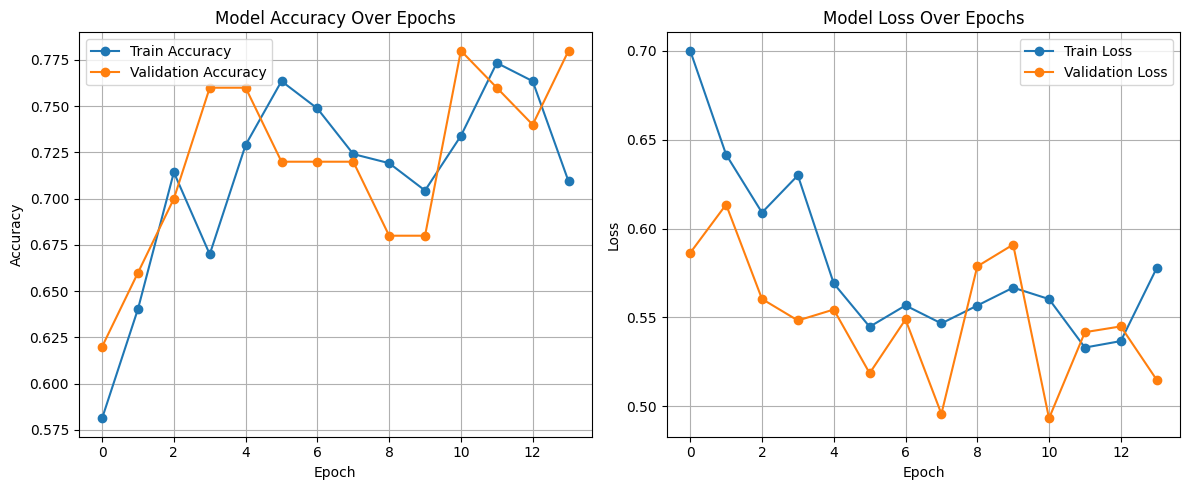

In [14]:

# Create a side-by-side figure with two plots
plt.figure(figsize=(12, 5))

# -------- Accuracy Plot --------
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# -------- Loss Plot --------
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], marker='o', label='Train Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Layout adjustment
plt.tight_layout()

# Show plot
plt.show()